# 03. Регрессионный анализ (OLS)

## Спецификация моделей

**Зависимая переменная:** `r_btc` — недельная логарифмическая доходность Bitcoin

**Модель 1 (крипто-факторы):**
$$r_{BTC,t} = \alpha + \beta_1 r_{BTC,t-1} + \beta_2 \ln Vol_t + \beta_3 GT_t + \varepsilon_t$$

**Модель 2 (внешние факторы):**
$$r_{BTC,t} = \alpha + \beta_1 r_{SP500,t} + \beta_2 VIX_t + \beta_3 r_{DXY,t} + \varepsilon_t$$

**Модель 3 (все факторы):**
$$r_{BTC,t} = \alpha + \beta_1 r_{BTC,t-1} + \beta_2 \ln Vol_t + \beta_3 GT_t + \beta_4 r_{SP500,t} + \beta_5 VIX_t + \beta_6 r_{DXY,t} + \varepsilon_t$$

## Гипотезы
- **H1:** Крипто-специфические факторы лучше объясняют доходность BTC, чем внешние
- **H2:** На более зрелом рынке (2020–2025) значимость внешних факторов возрастает

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson
import warnings
warnings.filterwarnings('ignore')

# Загружаем данные
df = pd.read_csv('../data/processed/merged_weekly.csv', index_col='date', parse_dates=True)

# Подпериоды
p1 = df.loc['2017-01-01':'2019-12-31']
p2 = df.loc['2020-01-01':'2025-03-01']

# Переменные
Y_VAR = 'r_btc'
CRYPTO_VARS = ['r_btc_lag', 'log_volume_btc', 'google_trends']
EXTERNAL_VARS = ['r_sp500', 'vix', 'r_dxy']
ALL_VARS = CRYPTO_VARS + EXTERNAL_VARS

var_labels = {
    'const': 'Константа',
    'r_btc_lag': 'BTC доходность (лаг)',
    'log_volume_btc': 'Log объём BTC',
    'google_trends': 'Google Trends',
    'r_sp500': 'S&P 500 доходность',
    'vix': 'VIX',
    'r_dxy': 'DXY доходность',
}

print('Данные загружены.')
print(f'Полный период: {len(df)} недель | P1: {len(p1)} | P2: {len(p2)}')

Данные загружены.
Полный период: 422 недель | P1: 153 | P2: 269


## 1. Вспомогательные функции

In [2]:
def run_ols(data, y_var, x_vars, se_type='HC3'):
    """
    OLS с робастными стандартными ошибками.
    se_type: 'OLS' — обычные SE, 'HC3' — робастные (White), 'HAC' — Newey-West
    """
    sample = data[[y_var] + x_vars].dropna()
    y = sample[y_var]
    X = sm.add_constant(sample[x_vars])

    model = sm.OLS(y, X).fit()

    if se_type == 'HC3':
        result = model.get_robustcov_results(cov_type='HC3')
    elif se_type == 'HAC':
        nw_lags = int(np.floor(4 * (len(sample)/100)**(2/9)))
        result = model.get_robustcov_results(cov_type='HAC', maxlags=nw_lags)
    else:
        result = model

    return result


def _to_array(x):
    """Приводит params/bse/tvalues/pvalues к numpy-массиву."""
    return np.asarray(x, dtype=float)


def extract_results(result, model_name=''):
    """Извлекает ключевые метрики и коэффициенты из результатов OLS."""
    names  = list(result.model.exog_names)
    params = _to_array(result.params)
    bse    = _to_array(result.bse)
    tvals  = _to_array(result.tvalues)
    pvals  = _to_array(result.pvalues)

    rows = []
    for i, var in enumerate(names):
        pval = float(pvals[i])
        stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
        rows.append({
            'Переменная': var_labels.get(var, var),
            'Коэф.':    round(float(params[i]), 4),
            'Ст. ош.':  round(float(bse[i]),    4),
            't-стат.':  round(float(tvals[i]),   3),
            'p-value':  round(pval,              4),
            'Знач.':    stars,
        })

    meta = pd.Series({
        'N':       int(result.nobs),
        'R²':      round(result.rsquared,     4),
        'Adj. R²': round(result.rsquared_adj, 4),
        'AIC':     round(result.aic,          2),
        'BIC':     round(result.bic,          2),
    }, name=model_name)

    return pd.DataFrame(rows).set_index('Переменная'), meta


print('Функции определены.')

Функции определены.


## 2. Полный период (2017–2025)

### 2.1 Модель 1: Крипто-специфические факторы

In [3]:
m1_ols = run_ols(df, Y_VAR, CRYPTO_VARS, se_type='OLS')
m1_hc3 = run_ols(df, Y_VAR, CRYPTO_VARS, se_type='HC3')
m1_hac = run_ols(df, Y_VAR, CRYPTO_VARS, se_type='HAC')

print('=== Модель 1: Крипто-факторы — Полный период ===')
print(m1_hac.summary())

=== Модель 1: Крипто-факторы — Полный период ===
                            OLS Regression Results                            
Dep. Variable:                  r_btc   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     1.413
Date:                Tue, 10 Mar 2026   Prob (F-statistic):              0.238
Time:                        02:39:55   Log-Likelihood:                 370.00
No. Observations:                 422   AIC:                            -732.0
Df Residuals:                     418   BIC:                            -715.8
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------

In [4]:
coef1, meta1 = extract_results(m1_hac, 'М1 (крипто)')
print('Коэффициенты (Newey-West SE):')
display(coef1)
print('\nМетрики:')
print(meta1.to_frame().T.to_string(index=False))

Коэффициенты (Newey-West SE):


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,0.0454,0.0420,1.082,0.2797,
BTC доходность (лаг),0.0685,0.0464,1.477,0.1404,
Log объём BTC,-0.0029,0.0026,-1.121,0.2628,
Google Trends,0.0002,0.0004,0.438,0.6616,



Метрики:
    N     R²  Adj. R²    AIC     BIC
422.0 0.0092   0.0021 -732.0 -715.82


### 2.2 Модель 2: Внешние рыночные факторы

In [5]:
m2_ols = run_ols(df, Y_VAR, EXTERNAL_VARS, se_type='OLS')
m2_hc3 = run_ols(df, Y_VAR, EXTERNAL_VARS, se_type='HC3')
m2_hac = run_ols(df, Y_VAR, EXTERNAL_VARS, se_type='HAC')

print('=== Модель 2: Внешние факторы — Полный период ===')
print(m2_hac.summary())

=== Модель 2: Внешние факторы — Полный период ===
                            OLS Regression Results                            
Dep. Variable:                  r_btc   R-squared:                       0.044
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     4.471
Date:                Tue, 10 Mar 2026   Prob (F-statistic):            0.00419
Time:                        02:39:55   Log-Likelihood:                 377.57
No. Observations:                 422   AIC:                            -747.1
Df Residuals:                     418   BIC:                            -731.0
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
co

In [6]:
coef2, meta2 = extract_results(m2_hac, 'М2 (внешние)')
display(coef2)

,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,0.0207,0.0147,1.407,0.1601,
S&P 500 доходность,0.7930,0.2399,3.305,0.0010,***
VIX,-0.0006,0.0007,-0.882,0.3784,
DXY доходность,-0.0906,0.6708,-0.135,0.8926,


### 2.3 Модель 3: Все факторы

In [7]:
m3_ols = run_ols(df, Y_VAR, ALL_VARS, se_type='OLS')
m3_hc3 = run_ols(df, Y_VAR, ALL_VARS, se_type='HC3')
m3_hac = run_ols(df, Y_VAR, ALL_VARS, se_type='HAC')

print('=== Модель 3: Все факторы — Полный период ===')
print(m3_hac.summary())

=== Модель 3: Все факторы — Полный период ===
                            OLS Regression Results                            
Dep. Variable:                  r_btc   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     2.601
Date:                Tue, 10 Mar 2026   Prob (F-statistic):             0.0174
Time:                        02:39:55   Log-Likelihood:                 378.34
No. Observations:                 422   AIC:                            -742.7
Df Residuals:                     415   BIC:                            -714.4
Df Model:                           6                                         
Covariance Type:                  HAC                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------

In [8]:
coef3, meta3 = extract_results(m3_hac, 'М3 (все)')
display(coef3)

,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,0.0296,0.0378,0.783,0.4343,
BTC доходность (лаг),0.0286,0.0497,0.574,0.5660,
Log объём BTC,-0.0014,0.0024,-0.577,0.5645,
Google Trends,0.0002,0.0003,0.578,0.5636,
S&P 500 доходность,0.7759,0.2378,3.263,0.0012,***
VIX,-0.0005,0.0007,-0.695,0.4873,
DXY доходность,-0.0618,0.6752,-0.092,0.9271,


### 2.4 Сравнение моделей — полный период

In [9]:
comparison_full = pd.DataFrame([meta1, meta2, meta3])
comparison_full.index = ['М1: Крипто-факторы', 'М2: Внешние факторы', 'М3: Все факторы']

print('=== Сравнение моделей (полный период 2017–2025, Newey-West SE) ===')
display(comparison_full)

print('\n*** p < 0.01  ** p < 0.05  * p < 0.1')

=== Сравнение моделей (полный период 2017–2025, Newey-West SE) ===


,N,R²,Adj. R²,AIC,BIC
М1: Крипто-факторы,422.0,0.0092,0.0021,-732.00,-715.82
М2: Внешние факторы,422.0,0.0441,0.0373,-747.15,-730.97
М3: Все факторы,422.0,0.0476,0.0338,-742.67,-714.36



*** p < 0.01  ** p < 0.05  * p < 0.1


## 3. Анализ по подпериодам

In [10]:
def run_all_models(data, period_name):
    """Запускает все 3 модели для заданного периода и возвращает результаты."""
    results = {}
    for model_name, x_vars in [
        ('М1: Крипто', CRYPTO_VARS),
        ('М2: Внешние', EXTERNAL_VARS),
        ('М3: Все', ALL_VARS)
    ]:
        r = run_ols(data, Y_VAR, x_vars, se_type='HAC')
        _, meta = extract_results(r, model_name)
        results[model_name] = meta
    return pd.DataFrame(results).T


print('=== ПОДПЕРИОД 1: 2017–2019 ===')
comp_p1 = run_all_models(p1, 'P1')
display(comp_p1)

print('\n=== ПОДПЕРИОД 2: 2020–2025 ===')
comp_p2 = run_all_models(p2, 'P2')
display(comp_p2)

=== ПОДПЕРИОД 1: 2017–2019 ===


,N,R²,Adj. R²,AIC,BIC
М1: Крипто,153.0,0.0096,-0.0104,-197.88,-185.76
М2: Внешние,153.0,0.0194,-0.0004,-199.40,-187.28
М3: Все,153.0,0.0248,-0.0153,-194.25,-173.04



=== ПОДПЕРИОД 2: 2020–2025 ===


,N,R²,Adj. R²,AIC,BIC
М1: Крипто,269.0,0.0245,0.0134,-559.04,-544.66
М2: Внешние,269.0,0.0893,0.0789,-577.53,-563.15
М3: Все,269.0,0.1016,0.0810,-575.19,-550.03


### 3.1 Детальные результаты по подпериодам — Модель 1 (крипто)

In [11]:
for period_name, data in [('Подпериод 1 (2017–2019)', p1), ('Подпериод 2 (2020–2025)', p2)]:
    r = run_ols(data, Y_VAR, CRYPTO_VARS, se_type='HAC')
    coef, meta = extract_results(r)
    print(f'\n=== Модель 1: Крипто — {period_name} ===')
    display(coef)
    print(f'R²={meta["R²"]:.4f}  Adj.R²={meta["Adj. R²"]:.4f}  N={meta["N"]}')


=== Модель 1: Крипто — Подпериод 1 (2017–2019) ===


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,0.1484,0.1243,1.194,0.2343,
BTC доходность (лаг),0.0034,0.0721,0.047,0.9628,
Log объём BTC,-0.0100,0.0091,-1.095,0.2753,
Google Trends,0.0004,0.0009,0.416,0.6777,


R²=0.0096  Adj.R²=-0.0104  N=153.0

=== Модель 1: Крипто — Подпериод 2 (2020–2025) ===


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,0.0238,0.0474,0.501,0.6166,
BTC доходность (лаг),0.1292,0.0573,2.254,0.0250,**
Log объём BTC,-0.0019,0.0028,-0.689,0.4917,
Google Trends,0.0002,0.0004,0.557,0.5782,


R²=0.0245  Adj.R²=0.0134  N=269.0


### 3.2 Детальные результаты по подпериодам — Модель 2 (внешние)

In [12]:
for period_name, data in [('Подпериод 1 (2017–2019)', p1), ('Подпериод 2 (2020–2025)', p2)]:
    r = run_ols(data, Y_VAR, EXTERNAL_VARS, se_type='HAC')
    coef, meta = extract_results(r)
    print(f'\n=== Модель 2: Внешние — {period_name} ===')
    display(coef)
    print(f'R²={meta["R²"]:.4f}  Adj.R²={meta["Adj. R²"]:.4f}  N={meta["N"]}')


=== Модель 2: Внешние — Подпериод 1 (2017–2019) ===


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,0.0602,0.0436,1.380,0.1696,
S&P 500 доходность,0.3194,0.7209,0.443,0.6583,
VIX,-0.0033,0.0026,-1.240,0.2167,
DXY доходность,-0.7269,1.3155,-0.553,0.5814,


R²=0.0194  Adj.R²=-0.0004  N=153.0

=== Модель 2: Внешние — Подпериод 2 (2020–2025) ===


,Коэф.,Ст. ош.,t-стат.,p-value,Знач.
Переменная,,,,,
Константа,0.0118,0.0125,0.945,0.3454,
S&P 500 доходность,0.9638,0.2121,4.544,0.0000,***
VIX,-0.0002,0.0006,-0.358,0.7208,
DXY доходность,0.3422,0.7151,0.478,0.6327,


R²=0.0893  Adj.R²=0.0789  N=269.0


### 3.3 Сводная сравнительная таблица подпериодов

In [13]:
def coef_table_by_period(x_vars, model_label):
    """Таблица коэффициентов для одной модели по трём периодам."""
    dfs = {}
    for period_name, data in [
        ('2017–2025', df),
        ('2017–2019', p1),
        ('2020–2025', p2)
    ]:
        r      = run_ols(data, Y_VAR, x_vars, se_type='HAC')
        names  = list(r.model.exog_names)
        params = _to_array(r.params)
        bse    = _to_array(r.bse)
        pvals  = _to_array(r.pvalues)

        rows = {}
        for i, var in enumerate(names):
            pval  = float(pvals[i])
            stars = '***' if pval < 0.01 else ('**' if pval < 0.05 else ('*' if pval < 0.1 else ''))
            rows[var_labels.get(var, var)] = f"{float(params[i]):.4f}{stars}\n({float(bse[i]):.4f})"
        rows['R²']      = f"{r.rsquared:.4f}"
        rows['Adj. R²'] = f"{r.rsquared_adj:.4f}"
        rows['N']       = str(int(r.nobs))
        dfs[period_name] = rows

    table = pd.DataFrame(dfs)
    print(f'\n=== {model_label} (Newey-West SE в скобках) ===')
    display(table)

coef_table_by_period(CRYPTO_VARS,   'Модель 1: Крипто-факторы')
coef_table_by_period(EXTERNAL_VARS, 'Модель 2: Внешние факторы')
coef_table_by_period(ALL_VARS,      'Модель 3: Все факторы')


=== Модель 1: Крипто-факторы (Newey-West SE в скобках) ===


,2017–2025,2017–2019,2020–2025
Константа,0.0454\n(0.0420),0.1484\n(0.1243),0.0238\n(0.0474)
BTC доходность (лаг),0.0685\n(0.0464),0.0034\n(0.0721),0.1292**\n(0.0573)
Log объём BTC,-0.0029\n(0.0026),-0.0100\n(0.0091),-0.0019\n(0.0028)
Google Trends,0.0002\n(0.0004),0.0004\n(0.0009),0.0002\n(0.0004)
R²,0.0092,0.0096,0.0245
Adj. R²,0.0021,-0.0104,0.0134
N,422,153,269



=== Модель 2: Внешние факторы (Newey-West SE в скобках) ===


,2017–2025,2017–2019,2020–2025
Константа,0.0207\n(0.0147),0.0602\n(0.0436),0.0118\n(0.0125)
S&P 500 доходность,0.7930***\n(0.2399),0.3194\n(0.7209),0.9638***\n(0.2121)
VIX,-0.0006\n(0.0007),-0.0033\n(0.0026),-0.0002\n(0.0006)
DXY доходность,-0.0906\n(0.6708),-0.7269\n(1.3155),0.3422\n(0.7151)
R²,0.0441,0.0194,0.0893
Adj. R²,0.0373,-0.0004,0.0789
N,422,153,269



=== Модель 3: Все факторы (Newey-West SE в скобках) ===


,2017–2025,2017–2019,2020–2025
Константа,0.0296\n(0.0378),0.1503\n(0.1228),0.0005\n(0.0428)
BTC доходность (лаг),0.0286\n(0.0497),-0.0257\n(0.0724),0.0735\n(0.0680)
Log объём BTC,-0.0014\n(0.0024),-0.0071\n(0.0080),-0.0010\n(0.0025)
Google Trends,0.0002\n(0.0003),0.0003\n(0.0009),0.0003\n(0.0004)
S&P 500 доходность,0.7759***\n(0.2378),0.3394\n(0.7397),0.9514***\n(0.2137)
VIX,-0.0005\n(0.0007),-0.0030\n(0.0026),0.0002\n(0.0007)
DXY доходность,-0.0618\n(0.6752),-0.6106\n(1.3789),0.4012\n(0.7143)
R²,0.0476,0.0248,0.1016
Adj. R²,0.0338,-0.0153,0.0810
N,422,153,269


## 4. Диагностические тесты

In [14]:
def diagnostics(result, model_name):
    """Диагностические тесты для OLS-модели."""
    resid = result.resid
    
    # Тест Бройша-Пагана на гетероскедастичность
    bp_stat, bp_p, _, _ = het_breuschpagan(resid, result.model.exog)
    
    # Тест Льюнга-Бокса на автокорреляцию остатков (лаг 5)
    lb_result = acorr_ljungbox(resid, lags=[5], return_df=True)
    lb_p = lb_result['lb_pvalue'].values[0]
    
    # Статистика Дарбина-Уотсона
    dw = durbin_watson(resid)
    
    print(f'{model_name}:')
    print(f'  Бройш-Паган (гетероск.): stat={bp_stat:.3f}, p={bp_p:.4f} {"→ гетероск." if bp_p < 0.05 else "→ норм."}')
    print(f'  Льюнг-Бокс (автокорр., lag=5): p={lb_p:.4f} {"→ автокорр." if lb_p < 0.05 else "→ норм."}')
    print(f'  Дарбин-Уотсон: {dw:.3f} {"(норм. ≈2)" if 1.5 < dw < 2.5 else "(!)"}') 
    print()

print('=== Диагностика — Полный период ===\n')
diagnostics(m1_ols, 'М1: Крипто-факторы')
diagnostics(m2_ols, 'М2: Внешние факторы')
diagnostics(m3_ols, 'М3: Все факторы')

=== Диагностика — Полный период ===

М1: Крипто-факторы:
  Бройш-Паган (гетероск.): stat=9.892, p=0.0195 → гетероск.
  Льюнг-Бокс (автокорр., lag=5): p=0.9104 → норм.
  Дарбин-Уотсон: 1.997 (норм. ≈2)

М2: Внешние факторы:
  Бройш-Паган (гетероск.): stat=15.359, p=0.0015 → гетероск.
  Льюнг-Бокс (автокорр., lag=5): p=0.8484 → норм.
  Дарбин-Уотсон: 1.951 (норм. ≈2)

М3: Все факторы:
  Бройш-Паган (гетероск.): stat=24.135, p=0.0005 → гетероск.
  Льюнг-Бокс (автокорр., lag=5): p=0.8720 → норм.
  Дарбин-Уотсон: 2.012 (норм. ≈2)



## 5. Визуализация коэффициентов по подпериодам

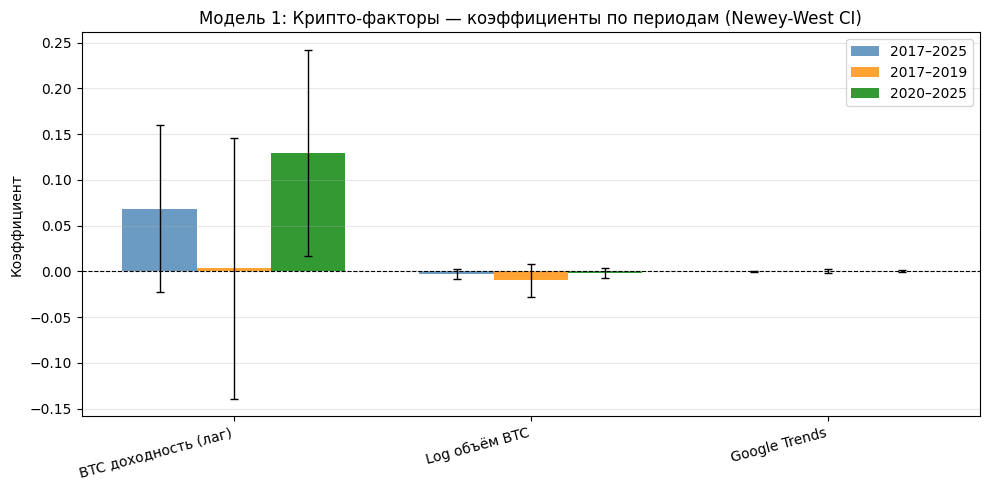

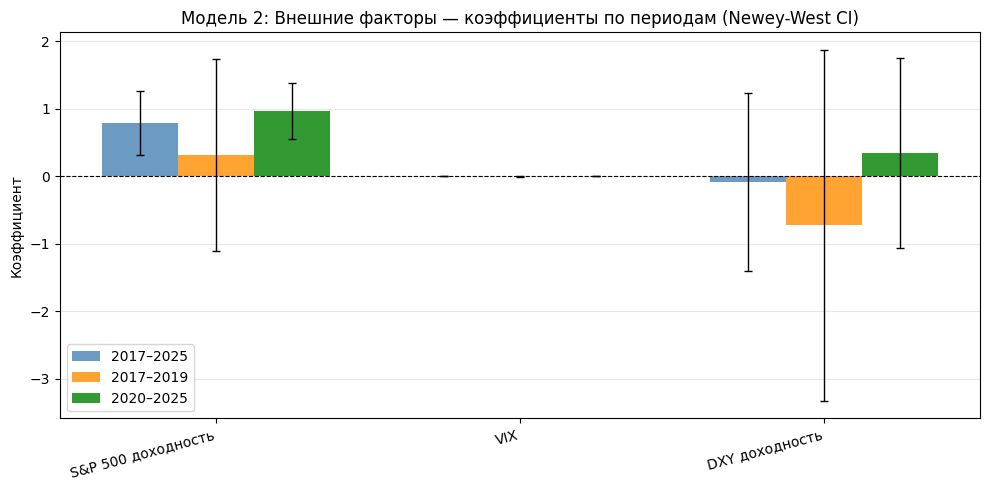

In [15]:
def plot_coef_comparison(x_vars, title):
    """График сравнения коэффициентов по трём периодам."""
    periods = {'2017–2025': df, '2017–2019': p1, '2020–2025': p2}
    colors  = {'2017–2025': 'steelblue', '2017–2019': 'darkorange', '2020–2025': 'green'}

    fig, ax = plt.subplots(figsize=(10, 5))
    width = 0.25
    x = np.arange(len(x_vars))

    for i, (period_name, data) in enumerate(periods.items()):
        r      = run_ols(data, Y_VAR, x_vars, se_type='HAC')
        names  = list(r.model.exog_names)
        params = _to_array(r.params)
        ci     = np.asarray(r.conf_int())          # shape (n_params, 2)

        idx    = [names.index(v) for v in x_vars]
        coefs      = [float(params[j]) for j in idx]
        errs_low   = [coefs[k] - float(ci[idx[k], 0]) for k in range(len(x_vars))]
        errs_high  = [float(ci[idx[k], 1]) - coefs[k] for k in range(len(x_vars))]

        ax.bar(
            x + (i - 1) * width, coefs, width,
            label=period_name, color=colors[period_name], alpha=0.8
        )
        ax.errorbar(
            x + (i - 1) * width, coefs,
            yerr=[errs_low, errs_high],
            fmt='none', color='black', capsize=3, linewidth=1
        )

    ax.set_xticks(x)
    ax.set_xticklabels([var_labels.get(v, v) for v in x_vars], rotation=15, ha='right')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(title)
    ax.set_ylabel('Коэффициент')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    return fig

fig1 = plot_coef_comparison(CRYPTO_VARS, 'Модель 1: Крипто-факторы — коэффициенты по периодам (Newey-West CI)')
fig1.savefig('../data/processed/reg_coef_crypto.png', dpi=100, bbox_inches='tight')
plt.show()

fig2 = plot_coef_comparison(EXTERNAL_VARS, 'Модель 2: Внешние факторы — коэффициенты по периодам (Newey-West CI)')
fig2.savefig('../data/processed/reg_coef_external.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Выводы по гипотезам

In [16]:
# Сводная таблица R² для обсуждения гипотез
r2_table = pd.DataFrame({
    'Модель': ['М1: Крипто-факторы', 'М2: Внешние факторы', 'М3: Все факторы'],
    'R² (полный)': [
        run_ols(df, Y_VAR, CRYPTO_VARS).rsquared,
        run_ols(df, Y_VAR, EXTERNAL_VARS).rsquared,
        run_ols(df, Y_VAR, ALL_VARS).rsquared,
    ],
    'R² (2017–2019)': [
        run_ols(p1, Y_VAR, CRYPTO_VARS).rsquared,
        run_ols(p1, Y_VAR, EXTERNAL_VARS).rsquared,
        run_ols(p1, Y_VAR, ALL_VARS).rsquared,
    ],
    'R² (2020–2025)': [
        run_ols(p2, Y_VAR, CRYPTO_VARS).rsquared,
        run_ols(p2, Y_VAR, EXTERNAL_VARS).rsquared,
        run_ols(p2, Y_VAR, ALL_VARS).rsquared,
    ],
}).set_index('Модель').round(4)

print('=== Сравнение R² по периодам ===')
display(r2_table)

print()
print('H1: Крипто-факторы лучше объясняют доходность BTC, чем внешние?')
m1_r2 = run_ols(df, Y_VAR, CRYPTO_VARS).rsquared
m2_r2 = run_ols(df, Y_VAR, EXTERNAL_VARS).rsquared
print(f'  R²(М1={m1_r2:.4f}) vs R²(М2={m2_r2:.4f}) → {"H1 поддерживается" if m1_r2 > m2_r2 else "H1 отвергается"}')

print()
print('H2: В подпериоде 2020–2025 значимость внешних факторов возросла?')
ext_p1 = run_ols(p1, Y_VAR, EXTERNAL_VARS).rsquared
ext_p2 = run_ols(p2, Y_VAR, EXTERNAL_VARS).rsquared
print(f'  R²(M2, 2017-2019={ext_p1:.4f}) vs R²(M2, 2020-2025={ext_p2:.4f}) → {"H2 поддерживается" if ext_p2 > ext_p1 else "H2 отвергается"}')

=== Сравнение R² по периодам ===


,R² (полный),R² (2017–2019),R² (2020–2025)
Модель,,,
М1: Крипто-факторы,0.0092,0.0096,0.0245
М2: Внешние факторы,0.0441,0.0194,0.0893
М3: Все факторы,0.0476,0.0248,0.1016



H1: Крипто-факторы лучше объясняют доходность BTC, чем внешние?
  R²(М1=0.0092) vs R²(М2=0.0441) → H1 отвергается

H2: В подпериоде 2020–2025 значимость внешних факторов возросла?
  R²(M2, 2017-2019=0.0194) vs R²(M2, 2020-2025=0.0893) → H2 поддерживается
